### 인공지능 6주차

--- 
#### tanh 함수 확인해보기

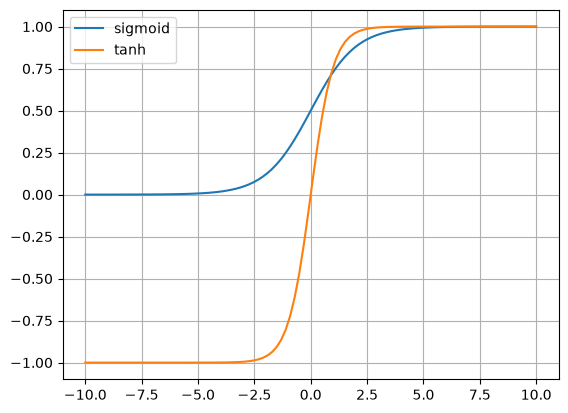

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    # return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
    return np.tanh(x)

x = np.linspace(-10,10, 100)

fig, ax = plt.subplots()
ax.plot(x, sigmoid(x), label = 'sigmoid')
ax.plot(x, tanh(x), label = 'tanh')

ax.grid()
ax.legend()

plt.show()

--- 
#### RNN 구현해보기

In [19]:
# RNN
import numpy as np

class RNN:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None
        
    def forward(self, x, h_prev):
        Wx, Wh, b = self.params
        t = np.matmul(h_prev, Wh) + np.matmul(x, Wx) + b
        h_next = np.tanh(t)
        self.cache = (x, h_prev, h_next)
        return h_next
    
    def backward(self, dh_next):
        Wx, Wh, b = self.params
        x, h_prev, h_next = self.cache
        
        dt = dh_next * (1- h_next**2) # tanh 역전파
        db = np.sum(dt, axis = 0) # 편항의 기울기
        
        dh_prev = np.matmul(dt, Wh.T)
        dWh = np.matmul(h_prev.T, dt)
        
        dx = np.matmul(dt, Wx.T)
        dWx = np.matmul(x.T, dt)

        self.grads[0][...] = dWx
        self.grads[1][...] = dWh
        self.grads[2][...] = db

        return dx, dh_prev

--- 
#### RNNLM

Embedding -> RNN -> Affine -> softmax

In [20]:
# Time Embedding
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None
        
    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out
    
    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0 # dW내 모든 원소를 0으로 변경
        
        for i, word_id in enumerate(self.idx): # 중복 인덱스 처리
            dW[word_id] += dout[i]
        return None
    
class TimeEmbedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.layers = None
        self.W = W

    def forward(self, xs):
        N, T = xs.shape
        V, D = self.W.shape

        out = np.empty((N, T, D), dtype='f')
        self.layers = []

        for t in range(T):
            layer = Embedding(self.W)
            out[:, t, :] = layer.forward(xs[:, t])
            self.layers.append(layer)

        return out

    def backward(self, dout):
        N, T, D = dout.shape

        grad = 0
        for t in range(T):
            layer = self.layers[t]
            layer.backward(dout[:, t, :])
            grad += layer.grads[0]

        self.grads[0][...] = grad
        return None

In [21]:
#Time RNN
class TimeRNN:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None # layers: 다수의 RNN 계층을 리스트로 저장하는 용도
        
        self.h, self.dh = None, None # h: forward를 호출했을 때 마지막 RNN 은닉상태 저장
        self.stateful = stateful
        
    def set_state(self, h):
        self.h = h
    
    def reset_state(self):
        self.h = None
        
    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape # N: 미니배치 크기, T: 시계열 길이, D: 입력 벡터의 차원
        D, H = Wx.shape # 은닉상태의 차원 크기
        
        self.layers = [] # 단일 RNN 결과 저장
        hs = np.empty((N,T,H), dtype = 'f') # hs: 출력값 저장
        
        if not self.stateful or self.h is None: # state가 True 일때 실행
            self.h = np.zeros((N,H), dtype='f')
            
        for t in range(T):
            layer = RNN(*self.params) # *self.params: 리스트 원소들을 추출하여 인수로 전달
            self.h = layer.forward(xs[:,t,:], self.h) # forward(x, h_prev)
            hs[:,t,:] = self.h # 모든 정보를 hs가 가져간다.
            self.layers.append(layer)
        return hs
    
    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D, H = Wx.shape
        
        dxs = np.empty((N, T, D), dtype = 'f')
        dh = 0
        grads = [0,0,0]
        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh = layer.backward(dhs[:,t,:] + dh)
            dxs[:,t,:] = dx
            
            for i, grad in enumerate(layer.grads):
                grads[i] += grad
                
        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        self.dh = dh
        
        return dxs

In [22]:
# Time Affine
class TimeAffine:
    def __init__(self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None

    def forward(self, x):
        N, T, D = x.shape
        W, b = self.params

        rx = x.reshape(N*T, -1)
        out = np.dot(rx, W) + b
        self.x = x
        return out.reshape(N, T, -1)

    def backward(self, dout):
        x = self.x
        N, T, D = x.shape
        W, b = self.params

        dout = dout.reshape(N*T, -1)
        rx = x.reshape(N*T, -1)

        db = np.sum(dout, axis=0)
        dW = np.dot(rx.T, dout)
        dx = np.dot(dout, W.T)
        dx = dx.reshape(*x.shape)

        self.grads[0][...] = dW
        self.grads[1][...] = db
        return dx


In [23]:
# Time SoftmaxWithLoss
def softmax(x):
    if x.ndim == 2:
        x = x - x.max(axis=1, keepdims=True)
        x = np.exp(x)
        x /= x.sum(axis=1, keepdims=True)
    elif x.ndim == 1:
        x = x - np.max(x)
        x = np.exp(x) / np.sum(np.exp(x))

    return x

class TimeSoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None
        self.ignore_label = -1

    def forward(self, xs, ts):
        N, T, V = xs.shape

        if ts.ndim == 3:  # 정답 레이블이 원핫 벡터인 경우
            ts = ts.argmax(axis=2)

        mask = (ts != self.ignore_label)

        # 배치용과 시계열용을 정리(reshape)
        xs = xs.reshape(N * T, V)
        ts = ts.reshape(N * T)
        mask = mask.reshape(N * T)

        ys = softmax(xs)
        ls = np.log(ys[np.arange(N * T), ts])
        ls *= mask  # ignore_label에 해당하는 데이터는 손실을 0으로 설정
        loss = -np.sum(ls)
        loss /= mask.sum()

        self.cache = (ts, ys, mask, (N, T, V))
        return loss

    def backward(self, dout=1):
        ts, ys, mask, (N, T, V) = self.cache

        dx = ys
        dx[np.arange(N * T), ts] -= 1
        dx *= dout
        dx /= mask.sum()
        dx *= mask[:, np.newaxis]  # ignore_label에 해당하는 데이터는 기울기를 0으로 설정

        dx = dx.reshape((N, T, V))

        return dx

In [24]:
# Simple RNNLM
class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 가중치 초기화
        embed_W = (rn(V, D) / 100).astype('f')
        rnn_Wx = (rn(D, H) / np.sqrt(D)).astype('f')
        rnn_Wh = (rn(H, H) / np.sqrt(H)).astype('f')
        rnn_b = np.zeros(H).astype('f')
        affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_W),
            TimeRNN(rnn_Wx, rnn_Wh, rnn_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]

        # 모든 가중치와 기울기를 리스트에 모은다.
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)
        loss = self.loss_layer.forward(xs, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.rnn_layer.reset_state()


--- 
#### LAB1: You say goodbye and I say hello .

In [ ]:
sentences = [
    "you say goodbye and I say hello <eos>".split(),
    "I say hello and you say goodbye <eos>".split(),
    "you say goodbye and you say goodbye <eos>".split(),
    "I say hello and I say hello <eos>".split(),
]

words = list(dict.fromkeys(
    word for sentence in sentences for word in sentence
))

word_to_id = {word: i for i, word in enumerate(words)}
id_to_word = {i: word for i, word in enumerate(words)}

xs = np.array([
    [word_to_id[word] for word in sentence[:-1]]
    for sentence in sentences
])

ts = np.array([
    [word_to_id[word] for word in sentence[1:]]
    for sentence in sentences
])

for sentence in sentences:
    print(" ".join(sentence))


In [31]:
def predict_next_word(model, text):
    model.reset_state()

    for word in text.split():
        score = np.array([[word_to_id[word]]])

        for layer in model.layers:
            score = layer.forward(score)

    probability = softmax(score[0, -1])
    next_id = int(np.argmax(probability))

    return id_to_word[next_id], probability


In [ ]:
hidden_sizes = [2, 4, 8, 16, 32]
learning_rate = 0.1
epochs = 2000

texts = [
    "you say",
    "I say",
    "you say goodbye and",
    "I say hello and",
    "you say goodbye and I say",
    "I say hello and you say",
    "you say goodbye and I say hello",
    "I say hello and you say goodbye",
]

label_width = 43
word_text = " ".join(f"{word:>7}" for word in words)

for hidden_size in hidden_sizes:
    np.random.seed(0)

    model = SimpleRnnlm(
        vocab_size=len(words),
        wordvec_size=8,
        hidden_size=hidden_size
    )

    for epoch in range(epochs):
        model.reset_state()
        loss = model.forward(xs, ts)
        model.backward()

        for param, grad in zip(model.params, model.grads):
            param -= learning_rate * grad

    print(f"\nhidden size: {hidden_size} | loss: {loss:.4f}")
    print("word list:".ljust(label_width) + word_text)

    for text in texts:
        next_word, probability = predict_next_word(model, text)
        probability_text = " ".join(
            f"{value * 100:6.2f}%" for value in probability
        )
        input_text = f"input {text}:"
        print(
            input_text.ljust(label_width)
            + probability_text
            + f" -> {next_word}"
        )


---
#### Lab2: 은닉 상태 크기별 확률 보기

In [39]:
def train_model(hidden_size, epochs=2000):
    np.random.seed(0)

    model = SimpleRnnlm(
        vocab_size=len(words),
        wordvec_size=8,
        hidden_size=hidden_size
    )

    learning_rate = 0.1

    for epoch in range(epochs):
        model.reset_state()

        loss = model.forward(xs, ts)
        model.backward()

        for param, grad in zip(model.params, model.grads):
            param -= learning_rate * grad

    return model, loss

hidden_sizes = [1, 2, 4, 8, 16, 32]
results = []

for hidden_size in hidden_sizes:
    model, loss = train_model(hidden_size)

    _, probability1 = predict_next_word(
        model,
        "you say"
    )

    _, probability2 = predict_next_word(
        model,
        "you say goodbye and I say"
    )

    goodbye_probability = probability1[word_to_id["goodbye"]]
    hello_probability = probability2[word_to_id["hello"]]

    results.append((
        hidden_size,
        loss,
        goodbye_probability,
        hello_probability
    ))

In [40]:
print(
    f"{'hidden':>8}"
    f"{'loss':>12}"
    f"{'goodbye':>14}"
    f"{'hello':>14}"
)

for hidden_size, loss, goodbye_probability, hello_probability in results:
    print(
        f"{hidden_size:>8}"
        f"{loss:>12.4f}"
        f"{goodbye_probability * 100:>13.2f}%"
        f"{hello_probability * 100:>13.2f}%"
    )

  hidden        loss       goodbye         hello
       1      0.6644        44.67%        44.72%
       2      0.1066        81.91%        89.69%
       4      0.0116        98.99%        98.21%
       8      0.0058        99.27%        99.17%
      16      0.0023        99.71%        99.76%
      32      0.0011        99.86%        99.89%
